In [1]:
# Large scale packages
import znnl as nl

# Linalg help
import numpy as onp
import jax.numpy as np
from flax.training import train_state
import flax.linen as nn
import optax
import jax
import neural_tangents as nt
from flax.core.frozen_dict import FrozenDict
from jax.tree_util import tree_flatten, tree_unflatten

# system and plotting help
import matplotlib.pyplot as plt
from dataclasses import dataclass
import copy
from rich.progress import track

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Data generation functions

In [2]:
def linear_boundary(
    data: np.ndarray, gradient: float = -1.0, intercept: float = 1.0
):
    """
    Create a linear boundary between classes.
    
    Parameters
    ----------
    data : np.ndarray (n_samples, 2)
            Data to be converted into classes.
    gradient : float (default = 1.0)
            Gradient of the line, default 1.0.
    intercept : float (default = 1.0)
            Intercept of the line, default 1.0.
    """
    # y = m * x + c
    reference_values = gradient * data[:, 0] + intercept
    
    
    differences = data[:, 1] - reference_values
    differences[differences > 0] = 1
    differences[differences < 0.] = 0
    
    return differences

class Generator(nl.data.DataGenerator):
    def __init__(self, n_samples: int, discriminator: callable = linear_boundary):
        """
        Instantiate the class.
       
        Parameters
        ----------
        n_samples : int
                Number of samples to generate.
        discriminator : callable
                Function to map x, y values to a class.
        """
        # Create the data-sets
        train_data = onp.array(jax.random.uniform(
            jax.random.PRNGKey(0), minval=0., maxval=1., shape=(n_samples, 2)
        ))
        train_targets = discriminator(train_data).reshape(-1, 1)  # build classes (0, 1)
        
        self.train_ds = {
            "inputs": train_data,
            "targets": train_targets
        }
        
        test_data = onp.array(jax.random.uniform(
            jax.random.PRNGKey(10), minval=0., maxval=1., shape=(n_samples, 2)
        ))
        test_targets = discriminator(test_data).reshape(-1, 1)  # build classes (0, 1)
        
        self.test_ds = {
            "inputs": test_data,
            "targets": test_targets
        }
        

In [10]:
generator = Generator(1000)

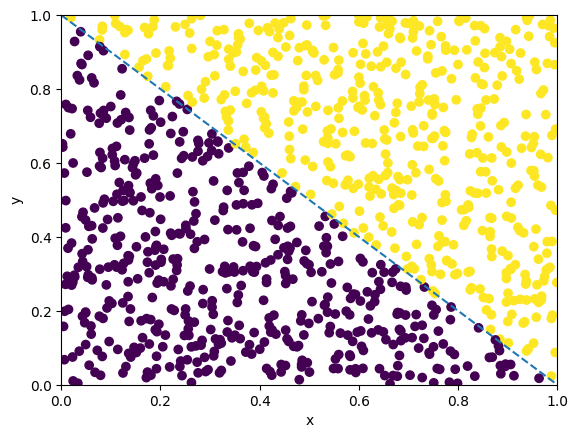

In [12]:
points = generator.train_ds["inputs"]
colours = generator.train_ds["targets"]

x = np.linspace(0, 1)
y = -1 * x + 1.0

plt.scatter(
    points[:, 0], points[:, 1], c=colours
)
plt.plot(x, y, "--")

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("decision-boundary.png")
plt.show()

## Model Building Functions

In [3]:
def build_network(width: int, depth: int):
    """
    Construct a flax model with seperate layers.
    
    Parameters
    ----------
    width : int
            How many unit in hidden layers.
    depth : int
            How many hidden layers.
    """
    # Template of a layer.
    class HiddenLayer(nn.Module):
        @nn.compact
        def __call__(self, x):
            """
            Call method for hidden layer.
            """
            x = nn.Dense(width)(x)
            x = nn.relu(x)
            
            return x
        
    class Model(nn.Module):
        def setup(self):
            self.hidden_layers = [
                HiddenLayer() for _ in range(depth)
            ]
            
        @nn.compact
        def __call__(self, x):
            """
            Call method for entire model.
            """
            for item in self.hidden_layers:
                x = item(x)
                
            # Output layer
            x = nn.Dense(1)(x)
            
            return x
        
    return Model

## Model Training Functions

In [4]:
def create_train_state(module, rng, learning_rate):
    """Creates an initial TrainState."""

    params = module.init(rng, np.ones([1, 2]))['params']

    tx = optax.adam(learning_rate)

    return train_state.TrainState.create(
      apply_fn=module.apply, params=params, tx=tx,
    )

In [5]:
@jax.jit
def train_step(state, batch):
    """Train for a single step."""

    def loss_fn(params):
        logits = state.apply_fn({'params': params}, batch['inputs'])

        loss = ((logits - batch["targets"]) ** 2).mean()

        return loss

    grad_fn = jax.value_and_grad(loss_fn)
    loss, grads = grad_fn(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss

In [6]:
def get_ntk_function(apply_fn, batch_size: int):
    empirical_ntk = nt.empirical_ntk_fn(
        f=apply_fn, 
        trace_axes=(-1,),
        implementation=nt.NtkImplementation.JACOBIAN_CONTRACTION
    )
    
    return jax.jit(empirical_ntk)


In [7]:
def train_model(
    n_epochs: int, batch_size: int, learning_rate: float, model: nn.Module, generator: Generator,
):

    # Seed the model state.
    init_rng = jax.random.PRNGKey(onp.random.randint(76325426354))
    state = create_train_state(model, init_rng, learning_rate)
    del init_rng

    # f(x, \theta)
    def apply_fn(params, x):
        return model.apply({"params":params}, x, mutable=['batch_stats'])[0]

    params = []
    train_losses = []

    for epoch in track(range(n_epochs), description="Working..."):

        # Perform training steps over batches
        train_ds_size = len(generator.train_ds["inputs"])
        steps_per_epoch = train_ds_size // batch_size

        # Prepare the shuffle.
        rng = jax.random.PRNGKey(onp.random.randint(764357264952))
        permutations = jax.random.permutation(rng, train_ds_size)
        permutations = np.array_split(permutations, steps_per_epoch)

        # Step over items in batch.
        for permutation in permutations:
            batch = {k: v[permutation, ...] for k, v in generator.train_ds.items()}
            state, loss = train_step(state, batch)
            train_losses.append(loss)
            
        if epoch % 50 == 0:
            params.append(copy.deepcopy(state.params))
        
    return params, train_losses


## Analysis Functions

In [8]:
def compute_entropy(matrix: np.ndarray):
    """
    Compute the entropy observable.
    """
    values, vectors = np.linalg.eigh(matrix)
    values /= values.sum()
    values = np.clip(values, 1e-8, None)
    
    return (-1 * values * np.log(values)).sum()

In [9]:
def compute_trace(matrix: np.ndarray):
    """
    Compute the trace observable
    """
    return np.trace(matrix)

In [10]:
def compute_self_msd(trajectory: np.ndarray):
    """
    Compute the msd of a trajectory.
    """
    square_difference = (trajectory - trajectory[0]) ** 2
    
    return np.mean(square_difference, axis=0)

In [11]:
def compute_cross_msd(trajectory: np.ndarray):
    """
    Compute the cross msd.
    """
    raise NotImplementedError("Not implemented yet")

In [12]:
def compute_class_entropy(dataset: dict, ntk: np.ndarray):
    """
    Compute the entropy of the classes only matrix.
    """
    # Collect class data-sets
    class_one_indices = np.where(dataset["targets"] == 0)[0]
    class_two_indices = np.where(dataset["targets"] == 1)[0]
    
    class_one_ntk = np.take(
        np.take(
            ntk, class_one_indices, axis=0
        ),
        class_one_indices, axis=1
    )
    class_two_ntk = np.take(
        np.take(
            ntk, class_two_indices, axis=0
        ),
        class_two_indices, axis=1
    )
    
    class_one_entropy = compute_entropy(
        class_one_ntk
    )
    class_two_entropy = compute_entropy(
        class_two_ntk
    )
    
    full_entropy = compute_entropy(
        ntk
    )
    
    return {
        "one": class_one_entropy, 
        "two": class_two_entropy, 
        "total": full_entropy, 
        "cross": (full_entropy - class_one_entropy - class_two_entropy) / 2
    }

In [13]:
def compute_fisher_matrix(
    params: dict, apply_fn: callable, dataset: dict
):
    """
    Compute the Fisher information matrix.
    """
    # Compute gradient vectors
    def _forward_pass(params, data):
        """
        Run the forward pass.
        """
        return apply_fn({"params": params}, data)
    
    grad_fn = jax.grad(_forward_pass)
    
    grads = grad_fn(
        params, dataset["params"]
    )
    
    fisher_matrix = np.zeros(
        (grads.shape[-1], grads.shape[-1])
    )
    for gradient in track(grads):
        fisher_matrix += np.einsum("i, j -> ij", gradient, gradient)
    
    return fisher_matrix / grads.shape[0]  # take the mean

In [14]:
def compute_radius_of_gyration(trajectory: np.ndarray):
    """
    Compute the radius of gyration for each class.
    """
    raise NotImplementedError("Not implemented yet")

## Experiment Helpers

In [15]:
@dataclass
class Experiment:
    # Experiment Parameters
    loss_fn: str
    width: int
    depth: int
    learning_rate: float
    optimizer: str
    epochs: int
    batch_size: int
    ds_size: int
    
    # Results
    parameters: list
    train_loss: np.ndarray


# Experiment 1: Linear Boundary

In [16]:
def main(
    ds_size: int = 500, 
    learning_rate: float = 1e-3,
    batch_size: int = 128,
    epochs: int = 5000
):
    """
    Run the experiment.
    """
    layer_sizes = [10, 128, 256]
    depths = [1, 2, 3]
    
    experiment_results = []

    for depth in depths:
        for width in layer_sizes:
            # Create data-set
            generator = Generator(n_samples=500)
            
            # Create the model
            model = build_network(width=width, depth=depth)()
            
            # Run the training
            param_list, train_loss = train_model(
                n_epochs=epochs, 
                batch_size=batch_size,
                learning_rate=learning_rate,
                model=model,
                generator=generator
            )
            
            experiment_results.append(
                Experiment(
                    loss_fn="mse_order_2", 
                    width=width, 
                    depth=depth, 
                    learning_rate=learning_rate, 
                    optimizer="ADAM",
                    epochs=epochs,
                    batch_size=batch_size,
                    ds_size=ds_size,
                    parameters=param_list,
                    train_loss=train_loss
                )
            )
            
    onp.save("linear-boundary.npy", experiment_results)
            